In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold

In [ ]:
FILE = "dataset_B_05_2020 (1).csv"

df = pd.read_csv(FILE)

print("Shape dataset:", df.shape)
print("Jumlah data:", df.shape[0])
print("Jumlah kolom:", df.shape[1])

Shape dataset: (11430, 89)
Jumlah data: 11430
Jumlah kolom: 89


In [ ]:
urls = df["url"].copy()
labels = df["status"].copy()

# Hanya fitur numerik
X = df.drop(columns=["url", "status"])
X = X.select_dtypes(include=np.number)

print("\nShape fitur numerik:", X.shape)
df.head()


Shape fitur numerik: (11430, 87)


,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,0,1,0,45,-1,0,1,1,4,legitimate
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,phishing
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,0,...,1,0,0,14,4004,5828815,0,1,0,phishing
3,http://rgipt.ac.in,18,11,0,2,0,0,0,0,0,...,1,0,0,62,-1,107721,0,0,3,legitimate
4,http://www.iracing.com/tracks/gateway-motorspo...,55,15,0,2,2,0,0,0,0,...,0,1,0,224,8175,8725,0,0,6,legitimate


In [ ]:

print("Total missing value:", X.isna().sum().sum())

X = X.fillna(X.median())


Total missing value: 0


In [ ]:
selector = VarianceThreshold(threshold=0)

X_selected = selector.fit_transform(X)

selected_features = X.columns[
    selector.get_support()
]

X_selected = pd.DataFrame(
    X_selected,
    columns=selected_features
)

print("\nSetelah menghapus fitur konstan:")
print("Shape:", X_selected.shape)

print("Jumlah fitur:", len(selected_features))



Setelah menghapus fitur konstan:
Shape: (11430, 81)
Jumlah fitur: 81


In [ ]:
removed_features = X.columns[
    ~selector.get_support()
]

print("\nFitur yang dihapus karena konstan:")
for feature in removed_features:
    print("-", feature)

print("\nJumlah fitur dihapus:", len(removed_features))


Fitur yang dihapus karena konstan:
- nb_or
- ratio_nullHyperlinks
- ratio_intRedirection
- ratio_intErrors
- submit_email
- sfh

Jumlah fitur dihapus: 6


In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_selected)

print("\nSetelah StandardScaler:")
print("Shape:", X_scaled.shape)
df.head()


Setelah StandardScaler:
Shape: (11430, 81)


,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,0,1,0,45,-1,0,1,1,4,legitimate
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,phishing
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,0,...,1,0,0,14,4004,5828815,0,1,0,phishing
3,http://rgipt.ac.in,18,11,0,2,0,0,0,0,0,...,1,0,0,62,-1,107721,0,0,3,legitimate
4,http://www.iracing.com/tracks/gateway-motorspo...,55,15,0,2,2,0,0,0,0,...,0,1,0,224,8175,8725,0,0,6,legitimate


In [ ]:
from sklearn.preprocessing import normalize

X_cosine = normalize(
    X_scaled,
    norm="l2"
)

print("Shape:", X_cosine.shape)

Shape: (11430, 81)


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

K_range = range(2, 11)

cosine_similarity_scores = []

for k in K_range:

    print(f"Menjalankan K-Means untuk K={k}...")

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_cosine)

    # Cosine similarity data terhadap seluruh centroid
    similarities = cosine_similarity(
        X_cosine,
        kmeans.cluster_centers_
    )

    # Ambil similarity terhadap centroid cluster masing-masing data
    assigned_similarity = similarities[
        np.arange(len(X_cosine)),
        labels
    ]

    # Rata-rata similarity
    mean_similarity = assigned_similarity.mean()

    cosine_similarity_scores.append(
        mean_similarity
    )

    print(
        f"K={k} | "
        f"Mean Cosine Similarity={mean_similarity:.4f}"
    )

Menjalankan K-Means untuk K=2...
K=2 | Mean Cosine Similarity=0.2654
Menjalankan K-Means untuk K=3...
K=3 | Mean Cosine Similarity=0.3461
Menjalankan K-Means untuk K=4...
K=4 | Mean Cosine Similarity=0.3912
Menjalankan K-Means untuk K=5...
K=5 | Mean Cosine Similarity=0.4255
Menjalankan K-Means untuk K=6...
K=6 | Mean Cosine Similarity=0.4482
Menjalankan K-Means untuk K=7...
K=7 | Mean Cosine Similarity=0.4630
Menjalankan K-Means untuk K=8...
K=8 | Mean Cosine Similarity=0.4763
Menjalankan K-Means untuk K=9...
K=9 | Mean Cosine Similarity=0.4871
Menjalankan K-Means untuk K=10...
K=10 | Mean Cosine Similarity=0.4991


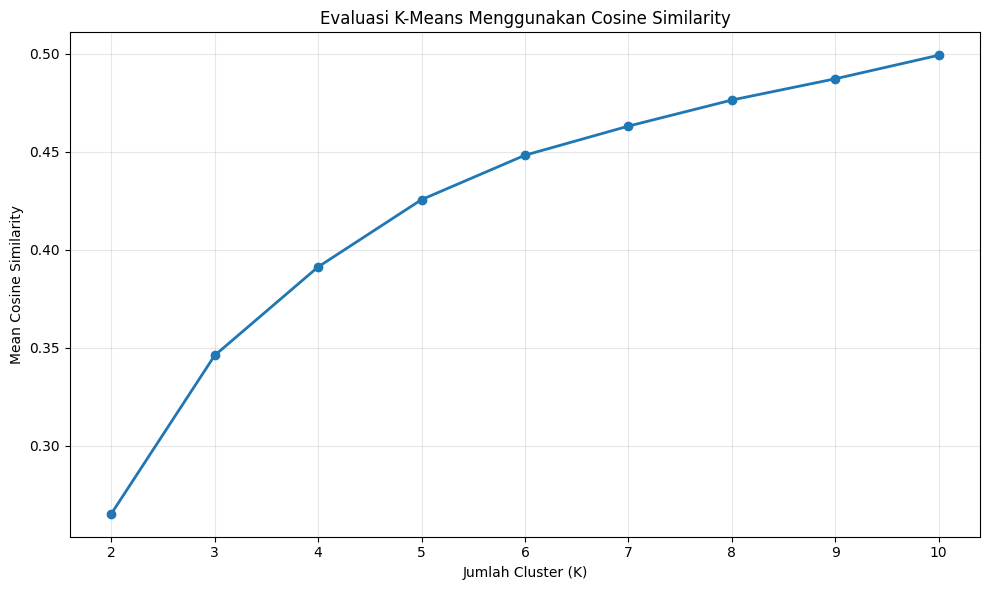

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    K_range,
    cosine_similarity_scores,
    marker="o",
    linewidth=2
)

plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("Mean Cosine Similarity")
plt.title("Evaluasi K-Means Menggunakan Cosine Similarity")

plt.xticks(list(K_range))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

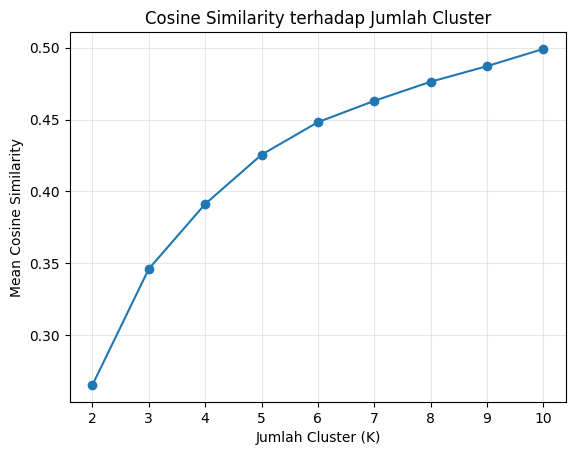

In [ ]:
plt.plot(
    K_range,
    cosine_similarity_scores,
    marker="o"
)

plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("Mean Cosine Similarity")
plt.title("Cosine Similarity terhadap Jumlah Cluster")

plt.xticks(list(K_range))
plt.grid(alpha=0.3)

plt.show()

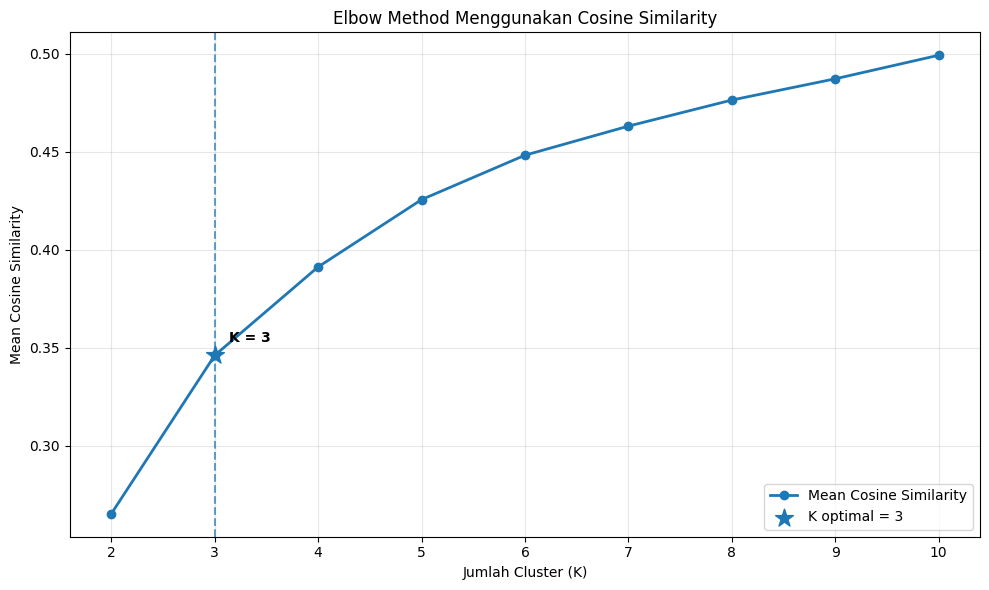

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    K_range,
    cosine_similarity_scores,
    marker="o",
    linewidth=2,
    label="Mean Cosine Similarity"
)

plt.scatter(
    optimal_k_cosine,
    cosine_similarity_scores[optimal_index],
    s=180,
    marker="*",
    zorder=5,
    label=f"K optimal = {optimal_k_cosine}"
)

plt.axvline(
    optimal_k_cosine,
    linestyle="--",
    alpha=0.7
)

plt.annotate(
    f"K = {optimal_k_cosine}",
    xy=(
        optimal_k_cosine,
        cosine_similarity_scores[optimal_index]
    ),
    xytext=(10, 10),
    textcoords="offset points",
    fontweight="bold"
)

plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("Mean Cosine Similarity")
plt.title("Elbow Method Menggunakan Cosine Similarity")

plt.xticks(list(K_range))
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
K_OPTIMAL = 3

kmeans_final = KMeans(
    n_clusters=K_OPTIMAL,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans_final.fit_predict(X_cosine)

print("K-Means selesai.")
print("K =", K_OPTIMAL)

print("\nDistribusi cluster:")
print(
    pd.Series(cluster_labels)
    .value_counts()
    .sort_index()
)

K-Means selesai.
K = 3

Distribusi cluster:
0    4488
1    4128
2    2814
Name: count, dtype: int64


Explained variance ratio:
[0.09903713 0.07858374]
Total variance 2D: 0.17762087070316396


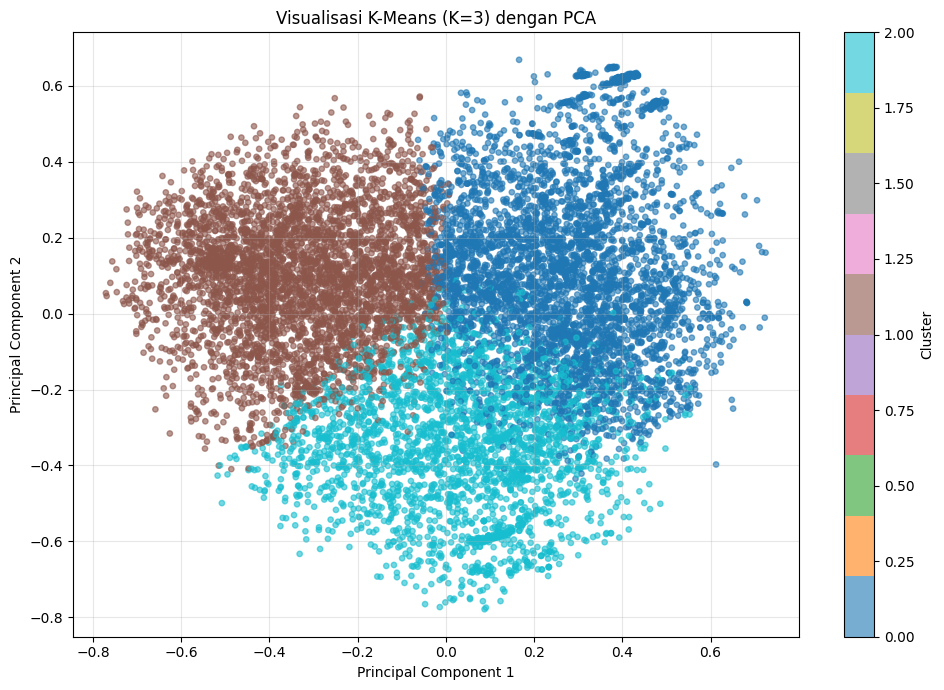

In [ ]:
from sklearn.decomposition import PCA

pca_vis = PCA(n_components=2)

X_2d = pca_vis.fit_transform(X_cosine)

print("Explained variance ratio:")
print(pca_vis.explained_variance_ratio_)

print(
    "Total variance 2D:",
    pca_vis.explained_variance_ratio_.sum()
)

plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=cluster_labels,
    cmap="tab10",
    s=15,
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title(
    f"Visualisasi K-Means (K={K_OPTIMAL}) "
    "dengan PCA"
)

plt.colorbar(
    scatter,
    label="Cluster"
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score

silhouette_cosine = silhouette_score(
    X_cosine,
    cluster_labels,
    metric="cosine"
)

print(
    f"Silhouette Score "
    f"(Cosine) = {silhouette_cosine:.4f}"
)

Silhouette Score (Cosine) = 0.1286
